In [191]:
import numpy as np
import pandas as pd

In [192]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Desktop\New folder (2)\titanic.csv")

In [193]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [194]:
df["number"].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'Passengers travelling with')

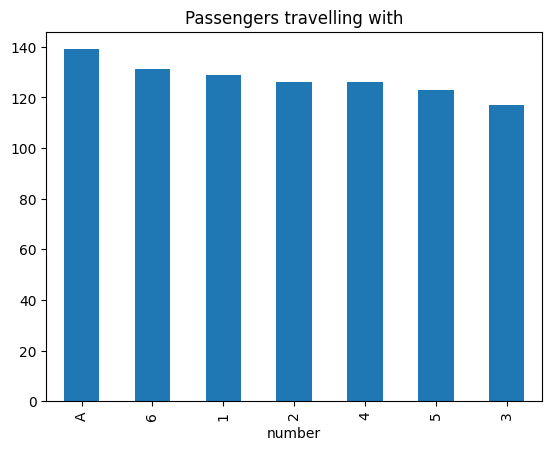

In [195]:
fig = df["number"].value_counts().plot.bar()
fig.set_title("Passengers travelling with")

In [196]:
# extract numerical part
df["number_numerical"] = pd.to_numeric(df["number"],errors="coerce",downcast="integer")  #T errors = coerce ->his handles invalid values.If a value cannot be converted (like "abc"), it becomes:NaN.
# downcast ->This tries to reduce memory usage.
# It converts numbers into the smallest possible integer type (like int8, int16 instead of int64).

In [197]:
# extract categorical part
df["number_categorical"] = np.where(df["number_numerical"].isnull(),df["number"],np.nan)
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [198]:
df["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [199]:
df["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [200]:
df["Cabin_num"] = df["Cabin"].str.extract(r"(\d+)") # captures numerical part
df["Cabin_cat"] = df["Cabin"].str[0] # captures the first letter
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,Cabin_num,Cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='Cabin_cat'>

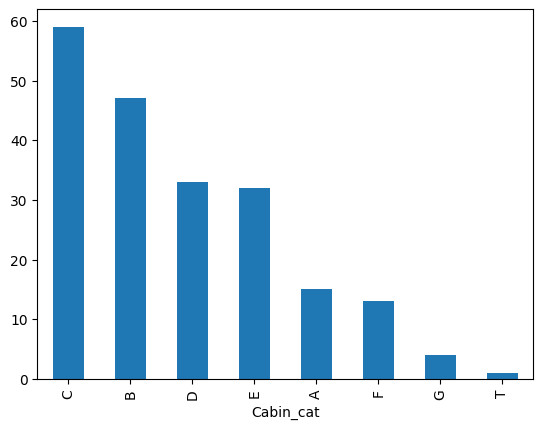

In [201]:
df["Cabin_cat"].value_counts().plot(kind="bar")

In [202]:
# extract the last bit of ticket as number 
df["ticket_num"] = df["Ticket"].apply(lambda s: s.split()[-1])
df["ticket_num"] = pd.to_numeric(df["ticket_num"],errors="coerce",downcast="integer")

# extract the first part of ticket as category 
df["ticket_cat"] = df["Ticket"].apply(lambda s: s.split()[0])
df["ticket_cat"] = np.where(df["ticket_cat"].str.isdigit(),np.nan,df["ticket_cat"])

df.head(20)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,Cabin_num,Cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN


# Handling Date and Time Variable ->


In [203]:
import numpy as np
import pandas as pd

In [204]:
date = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\orders.csv")
time = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\messages.csv")


In [205]:
date.head()  # ak dataset hain jo kis date par kon si city main kitni bar sell huwa woh bataya hain yeha.

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157
2,2018-10-23,1859,25,1
3,2019-08-17,7292,25,1
4,2019-01-06,4344,25,3


In [206]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [207]:
date.info()  # agar default main pandas main agar kavi dataset import karte hain toh uska jo date and time column hota hain woh by default object yani string hota hain .string hi rahe toh woh sab nehi kar paungi jo yeha par karna hain.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1000 non-null   object
 1   product_id  1000 non-null   int64 
 2   city_id     1000 non-null   int64 
 3   orders      1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


In [208]:
# CONVERTING TO DATETIME DATATYPE ->
date["date"] = pd.to_datetime(date["date"])
#Better for time analysis
#you can extract year, month, etc.
# date["date"]
#Left side → the column you want to update
#Right side → the column you want to convert


In [209]:
date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1000 non-null   datetime64[ns]
 1   product_id  1000 non-null   int64         
 2   city_id     1000 non-null   int64         
 3   orders      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 31.4 KB


In [210]:
# Extract  year ->
date["date_year"] = date["date"].dt.year  # dt matlab datetime aur jo vi information ayega woh pandas series main ayega aur isko date_year is column main dal diya.
date.head()

,date,product_id,city_id,orders,date_year
0,2019-12-10,5628,25,3,2019
1,2018-08-15,3646,14,157,2018
2,2018-10-23,1859,25,1,2018
3,2019-08-17,7292,25,1,2019
4,2019-01-06,4344,25,3,2019


In [211]:
# extract month ->
date["date_month"] = date["date"].dt.month
date.head()

,date,product_id,city_id,orders,date_year,date_month
0,2019-12-10,5628,25,3,2019,12
1,2018-08-15,3646,14,157,2018,8
2,2018-10-23,1859,25,1,2018,10
3,2019-08-17,7292,25,1,2019,8
4,2019-01-06,4344,25,3,2019,1


In [212]:
date["date_month_name"] = date["date"].dt.month_name()
date.head()

,date,product_id,city_id,orders,date_year,date_month,date_month_name
0,2019-12-10,5628,25,3,2019,12,December
1,2018-08-15,3646,14,157,2018,8,August
2,2018-10-23,1859,25,1,2018,10,October
3,2019-08-17,7292,25,1,2019,8,August
4,2019-01-06,4344,25,3,2019,1,January


In [213]:
# extract day ->
date["date_day"] = date["date"].dt.day
date.head()

,date,product_id,city_id,orders,date_year,date_month,date_month_name,date_day
0,2019-12-10,5628,25,3,2019,12,December,10
1,2018-08-15,3646,14,157,2018,8,August,15
2,2018-10-23,1859,25,1,2018,10,October,23
3,2019-08-17,7292,25,1,2019,8,August,17
4,2019-01-06,4344,25,3,2019,1,January,6


In [214]:
# day of week ->
# agar week ka kon sa din hain woh dekhna hain toh 
date["date_dow"] = date["date"].dt.dayofweek
date.head()


,date,product_id,city_id,orders,date_year,date_month,date_month_name,date_day,date_dow
0,2019-12-10,5628,25,3,2019,12,December,10,1
1,2018-08-15,3646,14,157,2018,8,August,15,2
2,2018-10-23,1859,25,1,2018,10,October,23,1
3,2019-08-17,7292,25,1,2019,8,August,17,5
4,2019-01-06,4344,25,3,2019,1,January,6,6


In [215]:
# day of week - name  ->

date["date_dow_name"] = date["date"].dt.day_name()
date.drop(columns=["product_id","city_id","orders"]).head()

,date,date_year,date_month,date_month_name,date_day,date_dow,date_dow_name
0,2019-12-10,2019,12,December,10,1,Tuesday
1,2018-08-15,2018,8,August,15,2,Wednesday
2,2018-10-23,2018,10,October,23,1,Tuesday
3,2019-08-17,2019,8,August,17,5,Saturday
4,2019-01-06,2019,1,January,6,6,Sunday


In [216]:
# is weekend ?

date["date_is_weekend"] = np.where(date["date_dow_name"].isin(["Sunday","Saturday"]),1,0)
date.drop(columns=["product_id","city_id","orders"]).head()

,date,date_year,date_month,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend
0,2019-12-10,2019,12,December,10,1,Tuesday,0
1,2018-08-15,2018,8,August,15,2,Wednesday,0
2,2018-10-23,2018,10,October,23,1,Tuesday,0
3,2019-08-17,2019,8,August,17,5,Saturday,1
4,2019-01-06,2019,1,January,6,6,Sunday,1


In [217]:
# extract week of the year ->
date["date_week"] = date["date"].dt.isocalendar().week
date.drop(columns=["product_id","city_id","orders"]).head()

,date,date_year,date_month,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43
3,2019-08-17,2019,8,August,17,5,Saturday,1,33
4,2019-01-06,2019,1,January,6,6,Sunday,1,1


In [218]:
# extract quarter
date["quater"] = date["date"].dt.quarter
date.drop(columns=["product_id","city_id","orders"]).head()

,date,date_year,date_month,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quater
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1


In [219]:
# extract Semester ->

date["semester"] = np.where(date["quater"].isin([1,2]),1,2)
date.drop(columns=["product_id","city_id","orders"]).head()

,date,date_year,date_month,date_month_name,date_day,date_dow,date_dow_name,date_is_weekend,date_week,quater,semester
0,2019-12-10,2019,12,December,10,1,Tuesday,0,50,4,2
1,2018-08-15,2018,8,August,15,2,Wednesday,0,33,3,2
2,2018-10-23,2018,10,October,23,1,Tuesday,0,43,4,2
3,2019-08-17,2019,8,August,17,5,Saturday,1,33,3,2
4,2019-01-06,2019,1,January,6,6,Sunday,1,1,1,1


In [220]:
# Extract Time elapsed between dates

import datetime

today = datetime.datetime.today()

today

datetime.datetime(2026, 4, 13, 23, 45, 44, 730820)

In [221]:
today - date["date"]

0     2316 days 23:45:44.730820
1     2798 days 23:45:44.730820
2     2729 days 23:45:44.730820
3     2431 days 23:45:44.730820
4     2654 days 23:45:44.730820
                 ...           
995   2744 days 23:45:44.730820
996   2685 days 23:45:44.730820
997   2533 days 23:45:44.730820
998   2598 days 23:45:44.730820
999   2372 days 23:45:44.730820
Name: date, Length: 1000, dtype: timedelta64[ns]

In [222]:
(today - date["date"]).dt.days

0      2316
1      2798
2      2729
3      2431
4      2654
       ... 
995    2744
996    2685
997    2533
998    2598
999    2372
Name: date, Length: 1000, dtype: int64

In [223]:
# Month passed ->

np.round((today-date["date"]) / np.timedelta64(1, "D") / 30,0)

0      77.0
1      93.0
2      91.0
3      81.0
4      88.0
       ... 
995    91.0
996    90.0
997    84.0
998    87.0
999    79.0
Name: date, Length: 1000, dtype: float64

In [224]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1000 non-null   object
 1   msg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [225]:
# converting to datetime datatype

time["date"] = pd.to_datetime(time["date"])

In [226]:
time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[ns]
 1   msg     1000 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 15.8+ KB


In [227]:
time["hour"] = time["date"].dt.hour
time["min"] = time["date"].dt.minute
time["sec"] = time["date"].dt.second

In [228]:
time.head()

,date,msg,hour,min,sec
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


In [229]:
# Extract Time part ->

time["time"] = time["date"].dt.time
time.head()

,date,msg,hour,min,sec,time
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0,00:50:00
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0,23:40:00
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0,00:21:00
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0,00:31:00
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0,23:11:00


In [230]:
# time difference ->
today - time["date"]

0     4502 days 22:55:44.730820
1     4367 days 00:05:44.730820
2     4852 days 23:24:44.730820
3     4154 days 23:14:44.730820
4     4552 days 00:34:44.730820
                 ...           
995   5141 days 22:55:44.730820
996   4463 days 00:31:44.730820
997   4928 days 00:08:44.730820
998   5044 days 00:11:44.730820
999   4316 days 00:20:44.730820
Name: date, Length: 1000, dtype: timedelta64[ns]

In [231]:
# in seconds ->
(today - time["date"]) / np.timedelta64(1, "s")

0      3.890553e+08
1      3.773091e+08
2      4.192971e+08
3      3.589893e+08
4      3.932949e+08
           ...     
995    4.442649e+08
996    3.856051e+08
997    4.257797e+08
998    4.358023e+08
999    3.729036e+08
Name: date, Length: 1000, dtype: float64

In [232]:
# in hour ->
(today - time["date"]) / np.timedelta64(1, "h")

0      108070.929092
1      104808.095759
2      116471.412425
3       99719.245759
4      109248.579092
           ...      
995    123406.929092
996    107112.529092
997    118272.145759
998    121056.195759
999    103584.345759
Name: date, Length: 1000, dtype: float64